# Импрорты и нужные классы

In [2]:
import sys
import os
import torch
import copy
import numpy as np
from dotenv import load_dotenv

sys.path.append('..')
env_file = os.path.join('..', '.env')
load_dotenv(env_file)
rowGlam_type = os.environ['ROW_GLAM_TYPE'] # custom or base
name_dataset = os.environ['NAME_DATASET']
name_test_dataset = os.environ['NAME_TEST_DATASET']
dataset_path = os.environ['DATASET_PATH']
test_path = os.environ['TEST_PATH']
test_coco_path = os.environ['TEST_COCO_PATH']
coco_path = os.environ['COCO_PATH']
cache_path = os.environ['CASH_PATH']
cache_pdf = os.environ['CASH_PDF_PATH']

In [3]:
from rows2regionsGLAM.utils.pdf_manager import PDFManager
from rows2regionsGLAM.utils.loger import Loger
from rows2regionsGLAM.utils.row_manager import RowManager
from rows2regionsGLAM.utils.ploter import Ploter
from rows2regionsGLAM.utils.trainer import Trainer
from rows2regionsGLAM.utils.tester import Tester
from rows2regionsGLAM.utils.cacher import Cacher
from rows2regionsGLAM.utils.coco_manager import COCOManager
from rows2regionsGLAM.utils.imbalance import calculate_imbalance
from rows2regionsGLAM.utils.tester import collect_maps, print_map_table

from rows2regionsGLAM.models.rowGLAM_base import TorchModelBase, PARAMS_BASE
from rows2regionsGLAM.models.rowGLAM_custom import TorchModel, PARAMS

from rows2regionsGLAM.tokenizers import RowGLAMTokenizer
from rows2regionsGLAM.converters import Rows2Regions
from rows2regionsGLAM.datasetloaders.base_line_dataset import GLAMDataset
from pager.page_model.sub_models.dtype import ImageSegment
from pager.page_model.sub_models import RegionModel, RowsModel

/Users/mike/lab/rows2regionsGLAM/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
loger = Loger('log.txt')
pdf_manager = PDFManager(conf={"loger": loger, "pdf_reader": "PDFMiner"})
row_manager = RowManager(conf={"loger": loger, "add_image": True})
coco_manager = COCOManager(conf={"loger": loger, "coco_path": coco_path})
ploter = Ploter(conf={"loger": loger})
tokenizer = RowGLAMTokenizer()
loger(tokenizer.get_name())

pdf2torch_dict = Cacher({
    "loger": loger,
    "pdf_manager": pdf_manager,
    "row_manager": row_manager,
    "tokenizer": tokenizer
})

# Проверка чтения файла

In [5]:
json_true_regions, CLASSES = coco_manager.get_regions_from_json()

In [6]:
CLASSES[3] = "text"
CLASSES

{1: 'text', 2: 'title', 3: 'text', 4: 'table', 5: 'figure', 0: 'other'}

In [7]:
file_names = list(json_true_regions.keys())
file_names.sort()

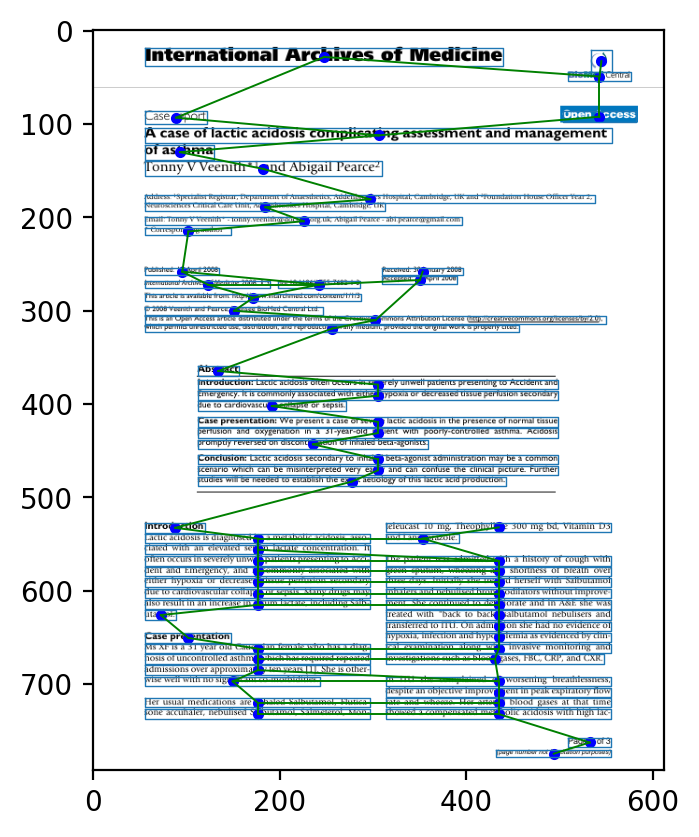

In [8]:
num_file = 1
file_name = file_names[num_file]
dataset_file = os.path.join(dataset_path, file_name)
pdf_json, pdf_img = pdf_manager.get_json_and_img_from_pdf(dataset_file, num_page=0)
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)
torch_dict = tokenizer(row_json, pdf_img)
ploter.set_dpi(200)
ploter.plot_img(pdf_img)
ploter.plot_tokens(tokenizer, torch_dict)

# Сохранение датасета

In [9]:
dataset = GLAMDataset({
    "loger": loger,
    "pdf_dir": dataset_path,
    "coco_file": coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
})

# Создание Cache
N = len(dataset)
for i, d in enumerate(dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

# Отрисовска файла из датасета

Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported
Cannot set non-stroke color because 2 components are specified but only 1 (grayscale), 3 (rgb) and 4 (cmyk) are supported


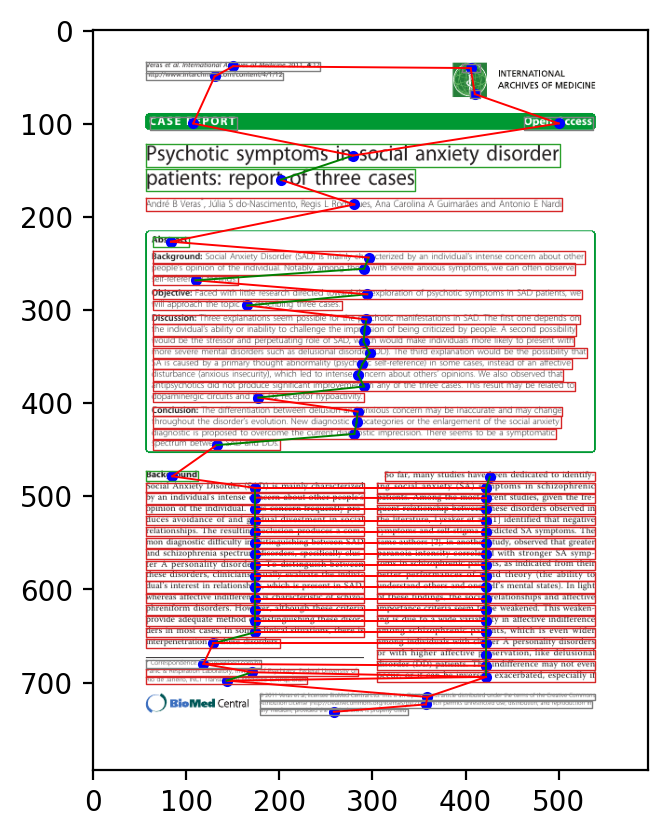

In [10]:
torch_dict2 = dataset[100]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
_, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
ploter.plot_tokens(tokenizer, torch_dict2, markup=True)

# Регионы --------------------------------------------------------------
# ann = coco_manager.get_regions_from_json()
# regions = ann[torch_dict2['file_name'] + ".pdf"]['regions']

# for reg in regions:
#     seg = ImageSegment(dict_p_size=reg['segment'])
#     seg.plot()

# Параметры модели

## Параметры модели первого типа

In [11]:
params_model_1  = {
    "node_featch": 15,
    "edge_featch": 4,
    "epochs": 30,
    "batch_size": 30,
    "learning_rate": 0.001,
    "model_type" : 1,
    "concat_gcn" : True,
    "mlp_pred":[
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 128}],
    "gcn_node":
         [
        {"linear_in" : -1,
        "batch_norm" : True, 
        "activation" : "gelu", 
        "aggregation" : "tag", 
        "K" : 3,
        "linear_out" : 256, 
        "size":128},

        {"linear_in" : -1, 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "K" : 3,
        "aggregation" : "tag", 
        "linear_out" : 256, 
        "size":64}
        ],

    "mlp_node_class":[
         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 128},
         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "softmax",
         "out" : 6}],

    "mlp_edge_class":
    [
         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : "gelu",
         "out" : 64},

         {"in" : -1, 
         "batch_norm" : True, 
         "activation" : None,
         "out" : 1}],

    "seg_k": 0.5,
    "loss_params": {
        "edge_coef": 0.8,
        "node_coef": 0.2,
    },
    "sigmoidEdge": False,
    "NodeClasses": 6
}

## Параметры модели второго типа

In [12]:
params_model_2  = {
    "node_featch": 15,
    "edge_featch": 4,
    "epochs": 30,
    "batch_size": 30,
    "learning_rate": 0.001,
    "model_type" : 2,
    "concat_gcn" : True,
    "mlp_pred":[
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 128}],
    "gcn_node":
        [
        {"linear_in" : -1,
        "batch_norm" : True, 
        "activation" : "gelu", 
        "aggregation" : "tag", 
        "K" : 3,
        "linear_out" : 256, 
        "size":128},

        {"linear_in" : -1, 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "K" : 3,
        "aggregation" : "tag", 
        "linear_out" : 256, 
        "size":64}
        ],

    "mlp_node_class":[
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 128},
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "softmax",
         "out" : 6}],
    "mlp_node_pred":[
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 128}],
    "gcn_node_post":
        [
        {"linear_in" : -1, # default -1: Повторить размерность прошлых слоев. 0 - не нужен линейный слой, в таком случае на Linear_out программа не обращает внимания 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "aggregation" : "tag", 
        "K" : 3, # Опционально, только проверяется только если tag
        "linear_out" : 256, 
        "size":128},

        {"linear_in" : -1, 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "K" : 3,
        "aggregation" : "tag", 
        "linear_out" : 256, 
        "size":128}
        ],

    "mlp_node_edge":
    [
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 128},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : None,
         "out" : 128}],
         
    "mlp_edge_class":
    [
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 64},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : None,
         "out" : 1}],

    "seg_k": 0.5,
    "loss_params": {
        "edge_coef": 0.8,
        "node_coef": 0.2,
    },
    "sigmoidEdge": False,
    "NodeClasses": 6
}

## Параметры моделей третьего типа

In [13]:
params_model_3  = {
    "node_featch": 15,
    "edge_featch": 4,
    "epochs": 30,
    "batch_size": 30,
    "learning_rate": 0.001,
    "model_type" : 3,
    "concat_gcn" : True,
    "mlp_pred":[
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 128}],
    "gcn_node":
        [
        {"linear_in" : -1, # default -1: Повторить размерность прошлых слоев. 0 - не нужен линейный слой, в таком случае на Linear_out программа не обращает внимания 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "aggregation" : "tag", 
        "K" : 3, # Опционально, только проверяется только если tag
        "linear_out" : 256, 
        "size":128},

        {"linear_in" : -1, 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "K" : 3,
        "aggregation" : "tag", 
        "linear_out" : 256, 
        "size":64}
        ],

    "mlp_node_class":[
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 128},
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "softmax",
         "out" : 6}],
    "mlp_edge_pred": [
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "softmax",
         "out" : 128}], 
    "gcn_edge":
        [
        {"linear_in" : -1, # default -1: Повторить размерность прошлых слоев. 0 - не нужен линейный слой, в таком случае на Linear_out программа не обращает внимания 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "aggregation" : "tag", 
        "K" : 3, # Опционально, только проверяется только если tag
        "linear_out" : 256, 
        "size":128},

        {"linear_in" : -1, 
        "batch_norm" : True, 
        "activation" : "gelu", 
        "K" : 3,
        "aggregation" : "tag", 
        "linear_out" : 256, 
        "size":128}
        ],

         
    "mlp_edge_class":
    [
         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 256},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : 64},

         {"in" : -1, 
         "batch_norm" : False, 
         "activation" : None,
         "out" : 1}],

    "seg_k": 0.5,
    "loss_params": {
        "edge_coef": 0.8,
        "node_coef": 0.2,
    },
    "sigmoidEdge": False,
    "NodeClasses": 6
}

In [14]:
import pandas as pd
import numpy as np
from typing import Dict, Any, Optional


class ExperimentTracker:
    """Класс для отслеживания результатов экспериментов моделей."""
    
    def __init__(self):
        """Инициализация трекера с пустой таблицей."""
        self.columns = ['model_name', 'mAP', 'f1_row_05', 'f1_row_95']
        self.df = pd.DataFrame(columns=self.columns)
    
    def add_experiment(
        self, 
        model_name: str, 
        map_score: float, 
        f1_row_05: float,
        f1_row_95: float
    ) -> None:
        """
        Добавление результатов эксперимента в таблицу.
        
        Parameters:
        -----------
        model_name : str
            Название модели
        map_score : float
            Значение метрики mAP
        f1_row_05 : float
            F1 score для строк при пороге 0.5
        f1_row_95 : float
            F1 score для строк при пороге 0.95
        """
        # Конвертация numpy типов в обычные float
        def to_float(value):
            if isinstance(value, (np.floating, np.float64, np.float32)):
                return float(value)
            return value
        
        row_data = {
            'model_name': model_name,
            'mAP': to_float(map_score),
            'f1_row_05': to_float(f1_row_05),
            'f1_row_95': to_float(f1_row_95)
        }
        
        # Добавление строки в DataFrame
        new_row = pd.DataFrame([row_data])
        self.df = pd.concat([self.df, new_row], ignore_index=True)
        
        print(f"✓ Добавлен эксперимент: {model_name}")
    
    def save_to_csv(
        self, 
        filepath: str = "experiment_results.csv",
        sep: str = ','
    ) -> None:
        """
        Сохранение таблицы в CSV файл.
        
        Parameters:
        -----------
        filepath : str
            Путь к файлу для сохранения
        sep : str
            Разделитель (по умолчанию запятая)
        """
        self.df.to_csv(filepath, index=False, sep=sep, float_format='%.4f')
        print(f"✓ Таблица сохранена в: {filepath}")
    
    def load_from_csv(
        self, 
        filepath: str,
        sep: str = ','
    ) -> None:
        """
        Загрузка таблицы из CSV файла.
        
        Parameters:
        -----------
        filepath : str
            Путь к файлу для загрузки
        sep : str
            Разделитель
        """
        self.df = pd.read_csv(filepath, sep=sep)
        print(f"✓ Загружено {len(self.df)} экспериментов из: {filepath}")
    
    def get_dataframe(self) -> pd.DataFrame:
        """Возвращает DataFrame с результатами."""
        return self.df.copy()

    


## Эксперименты

In [15]:
def build_params_exp1(model_type, has_linear, conv):
    match model_type:
        case 1:
            base_model_params = params_model_1
        case 2:
            base_model_params = params_model_2
        case 3:
            base_model_params = params_model_3

    if not has_linear:
        for key in base_model_params.keys():
            if "pred" in key:
                base_model_params[key] = None
    
    for key in base_model_params.keys():
        if "gcn" in key and not('concat' in key):
            for layer in base_model_params[key]:
                layer['aggregation'] = conv
    
    return base_model_params

def build_params_exp2(model, multiplier_mlp, multiplier_gcn):
    def build_mlp_layers(layers):
        mlp = [{"in" : -1, 
         "batch_norm" : False, 
         "activation" : "gelu",
         "out" : layer} for layer in layers]
        return mlp

    def build_gсn_layers(layers):
        gcn = [{"linear_in" : -1,
            "batch_norm" : True, 
            "activation" : "gelu", 
            "aggregation" : 'tag', 
            "K" : 3,
            "linear_out" : layer[1], 
            "size":layer[0]} for layer in layers]
        return gcn
    model_params = build_params_exp1(*model)
    base_model_params = model_params.copy()
    N_mlp = int(multiplier_mlp * len(base_model_params["mlp_edge_class"]))
    N_mlp = N_mlp + 1 if N_mlp <=1 else N_mlp
    N_gcn = int(multiplier_gcn * len(base_model_params["gcn_node"]))

    for key in base_model_params.keys():
        if "mlp" in key and base_model_params[key]!=None:

            first_size = base_model_params[key][0]['out']
            last_size = base_model_params[key][-1]['out']

            start = min(first_size, last_size)
            end = max(first_size, last_size)
            d = (end - start) / (N_mlp-1) if N_mlp != 1 else (end - start)

            layers = []
            for i in range(N_mlp):
                layers.insert(0, int(2**np.log2(start + i*d)))

            mlp = build_mlp_layers(layers)
            base_model_params[key] = mlp
        elif "gcn" in key and not("concat" in key):
            first_size_gcn = base_model_params[key][0]['size']
            last_size_gcn = base_model_params[key][-1]['size']
            first_size_linear = base_model_params[key][0]['linear_out']
            last_size_linear = base_model_params[key][-1]['linear_out']

            start_gcn, end_gcn = min(first_size_gcn, last_size_gcn), max(first_size_gcn, last_size_gcn)
            start_linear, end_linear = min(first_size_linear, last_size_linear), max(first_size_linear, last_size_linear)

            d_gcn = (end_gcn - start_gcn) / (N_gcn-1) if N_gcn != 1 else end_gcn - start_gcn
            d_mlp = (start_linear - end_linear) / (N_gcn-1) if N_gcn != 1 else start_linear - end_linear
            layers = []
            for i in range(N_gcn):
                layers.insert(0, 
                              (int(2**np.log2(start_gcn + i*d_gcn)), int(2**np.log2(start_linear + i*d_mlp))))
            gcn = build_gсn_layers(layers)
            base_model_params[key] = gcn
    for key in base_model_params.keys():
        if "node_class" in key:
            base_model_params[key][-1]['activation'] = "softmax"
        if "edge_class" in key:
            base_model_params[key][-1]['activation'] = None

    return base_model_params
            

## Эксперимент номер 1

In [ ]:
import itertools
test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": test_path,
    "coco_file": test_coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
    }
)
model_name = 'row2region_GLAM_artic'
model_types = [1, 2, 3]
convs = ['conv', 'gat', 'tag']
has_linear = [True, False]
exps = list(itertools.product(model_types, has_linear, convs))
print(np.__version__)
publaynet_imbalance, edge_imbalance = calculate_imbalance(dataset)
tracker = ExperimentTracker()
for i, exp in enumerate(exps):
    model_params = build_params_exp1(exp[0], exp[1], exp[2])
    model_params["epochs"] = 2
    model_params["batch_size"] = 80
    model_params["NodeClasses"] = len(CLASSES)
    model_params['loss_params']['publaynet_imbalance'] = publaynet_imbalance
    model_params['loss_params']['edge_imbalance'] = edge_imbalance

    model:torch.nn.Module = TorchModel(model_params)
    total_params = sum(p.numel() for p in model.parameters())  
    print(f"Number of parameters: {total_params}")
    model_name = f'Model number {i}'

    trainer_pub = Trainer(conf={"loger": loger, "params": model_params, "model_name": model_name})
    trainer_pub.start_train(5, dataset)

    model = TorchModel(model_params)
    model.load_state_dict(torch.load(model_name, weights_only=True))

    rows_model = RowsModel()
    region_model = RegionModel()
    rows2regions = Rows2Regions({
        'model':model, 
        'tokenizer': RowGLAMTokenizer(),
        'is_merge_extract': True,
        'classes': CLASSES
    })

    loger("Start Test")
    loger.time_log()

    N = len(test_dataset)
    for i, d in enumerate(test_dataset):
        print(f"{(i+1)/N*100:4.2f} %", end='\r')

    tester = Tester(conf={
    "loger": loger, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions})

    metrics = tester.calculate_target_and_preds(
        test_dataset, 
        name_dataset, 
        name_test_dataset, 
        dataset_path, 
        test_path
    )
    map_metric, grid_metric = tester.get_results(metrics)
    with open('results.txt', 'a') as file:
        file.write(f"{model_name}, map:{map_metric}, grid:{grid_metric} \n")

    tracker.add_experiment(
        model_name=str(exp),
        map_score=map_metric,
        grid_metrics=grid_metric
    )
tracker.save_to_html("experiment_results.html", title="ML Experiment Results")

## Эксперимент с числом слоев

In [ ]:
import json
import itertools

test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": test_path,
    "coco_file": test_coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
    }
)
publaynet_imbalance, edge_imbalance = calculate_imbalance(dataset)

models = ((1, False, 'tag'), (2, True, 'tag'))
multipliers_mlp = [0.25, 0.5, 1, 2]
multipliers_gcn = [0.5, 1, 2]
exps = list(itertools.product(models, multipliers_mlp, multipliers_gcn))
exp_model_params = []
for i, exp in enumerate(exps):
    model_params = build_params_exp2(*exp)
    model_params["epochs"] = 30
    model_params["batch_size"] = 128
    model_params["NodeClasses"] = len(CLASSES)
    model_params['loss_params']['publaynet_imbalance'] = publaynet_imbalance
    model_params['loss_params']['edge_imbalance'] = edge_imbalance
    exp_model_params.append(model_params)


for i, exp in enumerate(exp_model_params):
    with open("models.txt", 'a') as file:
        file.write(f"# Model numer {i} \n")
        file.write(json.dumps(exp, indent=4, ensure_ascii=False))
        file.write('\n\n')

tracker = ExperimentTracker()
for i, exp in enumerate(exp_model_params):
    model_params = exp


    model:torch.nn.Module = TorchModel(model_params)
    total_params = sum(p.numel() for p in model.parameters())  
    print(f"Number of parameters: {total_params}")
    model_name = f'Model number {i}'

    trainer_pub = Trainer(conf={"loger": loger, "params": model_params, "model_name": model_name})
    trainer_pub.start_train(5, dataset)

    model = TorchModel(model_params)
    model.load_state_dict(torch.load(model_name, weights_only=True))

    rows_model = RowsModel()
    region_model = RegionModel()
    rows2regions = Rows2Regions({
        'model':model, 
        'tokenizer': RowGLAMTokenizer(),
        'is_merge_extract': True,
        'classes': CLASSES
    })

    loger("Start Test")
    loger.time_log()

    N = len(test_dataset)
    for i, d in enumerate(test_dataset):
        print(f"{(i+1)/N*100:4.2f} %", end='\r')

    tester = Tester(conf={
    "loger": loger, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions})

    metrics = tester.calculate_target_and_preds(
        test_dataset, 
        name_dataset, 
        name_test_dataset, 
        dataset_path, 
        test_path
    )
    map_metric, grid_metric = tester.get_results(metrics)
    if grid_metric["threshold_05"]["f1_row"] is None:
        with open("error.txt", 'a') as file:
            file.write(model_params)
    model_name = "Новая " if exp[0][0] == 2 else "Старая "
    model_name += f"mlp_mul: {exp[1]}, gcn_mul: {exp[2]}"
    tracker.add_experiment(model_name=model_name,
                            map_score=map_metric,
                            f1_row_05=grid_metric["threshold_05"]["f1_row"],
                            f1_row_95=grid_metric["threshold_95"]["f1_row"])
    with open('results.txt', 'a') as file:
        file.write(f"{model_name}, map:{map_metric}, f1_row_05:{grid_metric["threshold_05"]["f1_row"]}, f1_row_95: {grid_metric["threshold_95"]["f1_row"]} \n")
tracker.save_to_csv()

TypeError: TextIOWrapper.write() takes exactly one argument (3 given)

# Обучение модели

In [ ]:
model:torch.nn.Module = TorchModel(model_params)
total_params = sum(p.numel() for p in model.parameters())  
print(f"Number of parameters: {total_params}") 

In [ ]:
trainer_pub = Trainer(conf={"loger": loger, "params": model_params, "model_name": model_name})
trainer_pub.start_train(5, dataset)

# Проверка работы модели

In [ ]:
model_params['sigmoidEdge'] = True

if rowGlam_type == "base":
    model = TorchModelBase(model_params)
elif rowGlam_type == "custom":
    model = TorchModel(model_params)

model.load_state_dict(torch.load(model_name, weights_only=True))

rows_model = RowsModel()
region_model = RegionModel()
rows2regions = Rows2Regions({
    'model':model, 
    'tokenizer': RowGLAMTokenizer(),
    'is_merge_extract': True,
    'classes': CLASSES
})

In [ ]:
torch_dict2 = dataset[126]
path_pdf = os.path.join(dataset_path, torch_dict2['file_name'] + ".pdf")
pdf_json, img = pdf_manager.get_json_and_img_from_pdf(path_pdf)
ploter.set_dpi(200)
ploter.plot_img(img)
# ploter.plot_tokens(tokenizer, torch_dict2)

# Регионы --------------------------------------------------------------
row_json = row_manager.get_row_json_from_pdf_json(pdf_json)

rows_model.from_dict({"rows": row_json})
rows2regions.convert(rows_model, region_model, img)

for reg in region_model.regions:
    reg.segment.plot(text=reg.label)

In [ ]:
test_dataset = GLAMDataset(
    {
    "loger": loger,
    "pdf_dir": test_path,
    "coco_file": test_coco_path,
    "count_class": len(CLASSES),
    "name_dataset": name_dataset,
    "default_index": 0,
    "cache_dir": cache_pdf,
    "pdf2torch_dict": pdf2torch_dict
    }
)

In [ ]:
loger("Start Test")
loger.time_log()

N = len(test_dataset)
for i, d in enumerate(test_dataset):
    print(f"{(i+1)/N*100:4.2f} %", end='\r')

In [ ]:
tester = Tester(conf={
    "loger": loger, 
    "pdf_manager": pdf_manager, 
    "row_manager": row_manager, 
    "rows_model": rows_model, 
    "region_model": region_model, 
    "rows2regions": rows2regions})

metrics = tester.calculate_target_and_preds(
    test_dataset, 
    name_dataset, 
    name_test_dataset, 
    dataset_path, 
    test_path
)

In [ ]:
tester.print_result(metrics)

In [ ]:
mAP@IoU[0.50:0.95]   :0.52044123
==================================================
threshold_05--------------------
precision_row       :0.8745
recall_row          :0.7442
f1_row              :0.8041
precision_word      :0.8312
recall_word         :0.7130
f1_word             :0.7676
threshold_95--------------------
precision_row       :0.7275
recall_row          :0.6222
f1_row              :0.6707
precision_word      :0.6884
recall_word         :0.5949
f1_word             :0.6382